In [1]:
words = open("names.txt", 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

Bigram model of language model. Only working with 2 characers at a time. What is the next character that follows X character.

In [6]:
for w in words[:1]:
    for c1, c2 in zip(w, w[1:]):
        print(c1, c2)

e m
m m
m a


In [7]:
list(w)

['e', 'm', 'm', 'a']

In [8]:
for w in words[:1]:
    # Add start and end special characters
    cs = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(cs, cs[1:]):
        print(c1, c2)

<S> e
e m
m m
m a
a <E>


Create Bigram distribution by counting instances of each character pair.

In [9]:
b = {}  # count for each bigram
for w in words:
    # Hallucinate start letter
    cs = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(cs, cs[1:]):
        bigram = (c1, c2)
        b[bigram] = b.get(bigram, 0) +1
        # print(c1, c2)

sort sorts by first value but we want to sort by second value which is the count

In [10]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

Store this bigram in 2D array:
rows: 1st character
cols: 2nd character

Array stores how likely the first character follows the second character in the dataset.

In [11]:
import torch

In [12]:
N = torch.zeros((28,28), dtype=torch.int32)

In [58]:
chars = sorted(list(set(''.join(words))))
# String to integer:
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = max(stoi.values())+1
stoi['<E>'] = max(stoi.values())+1

In [14]:
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [15]:
for w in words:
    cs = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(cs, cs[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        N[ix1, ix2] +=1

In [16]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

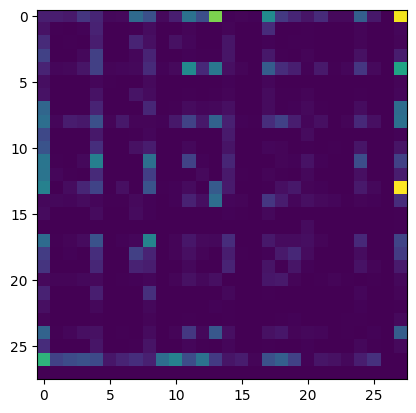

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

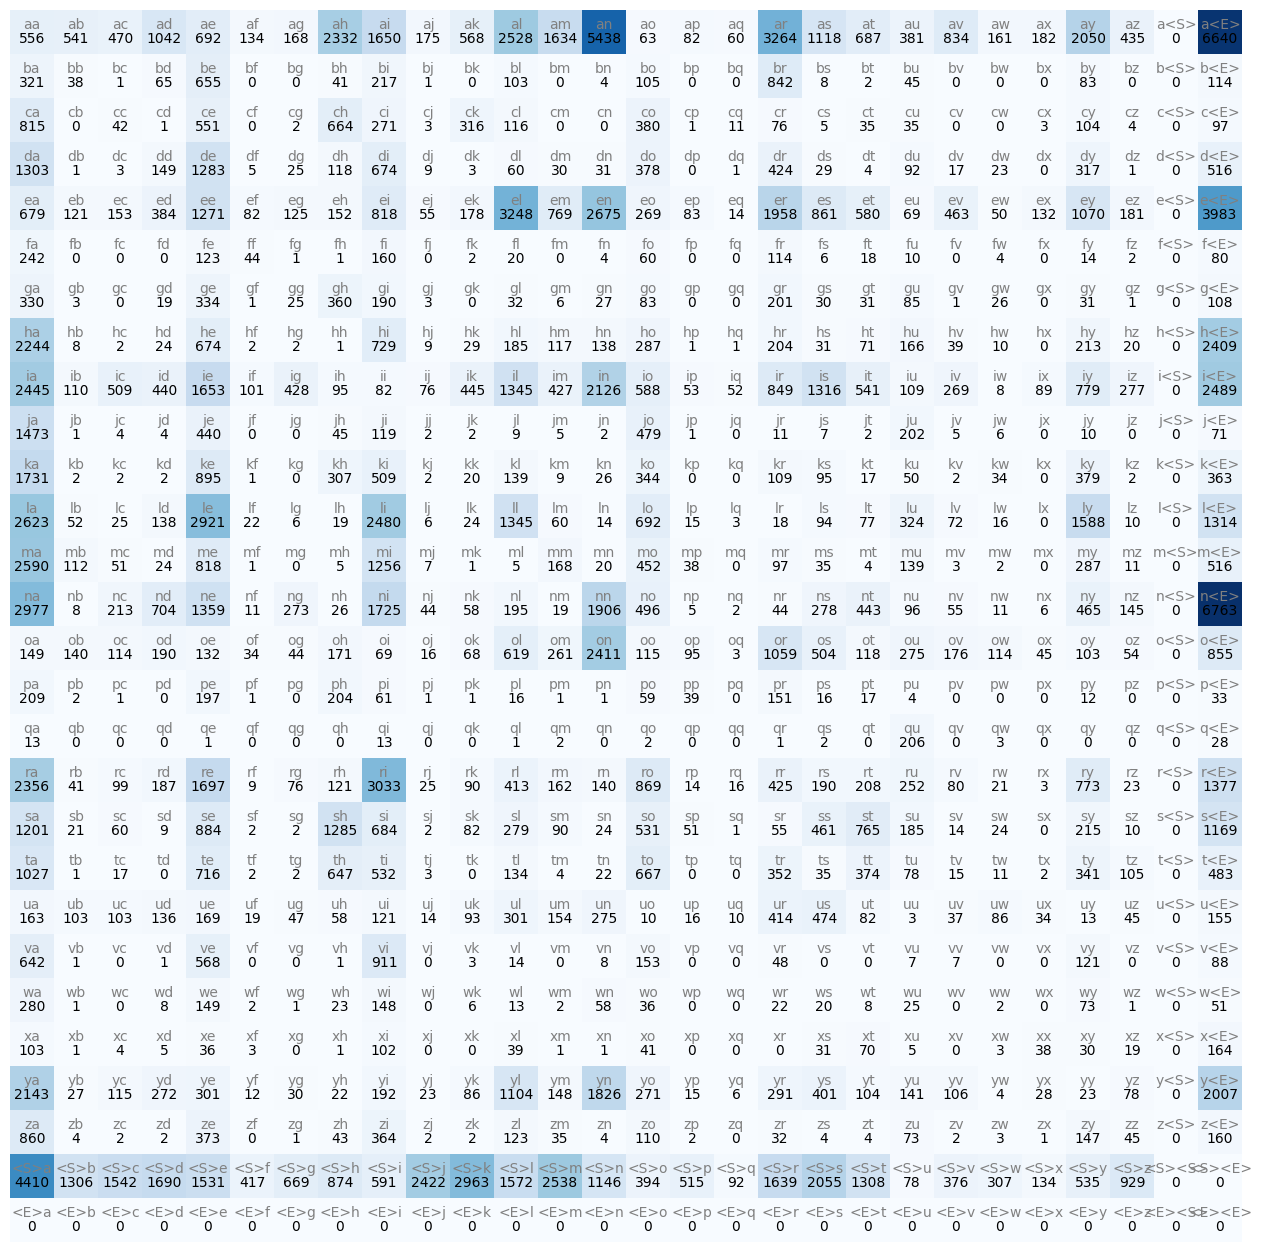

In [18]:
# Invert dictionary
itos = {i:s for s,i in stoi.items()}
itos

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')

for i in range(len(itos.keys())):
    for j in range(len(itos.keys())):
        cstr = itos[i] + itos[j]
        plt.text(j, i, cstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="black")
plt.axis("off")

Now we will do the same but optimising special tokens to remove files with 0 values.

In [19]:
chars = sorted(list(set(''.join(words))))
# String to integer:
stoi = {s:i+1 for i,s in enumerate(chars)}  # i+1 because we inserted special character at index 0
stoi['.'] = 0
# Invert dictionary
itos = {i:s for s,i in stoi.items()}

In [20]:
N = torch.zeros((len(stoi.values()),len(stoi.values())), dtype=torch.int32)

In [21]:
stoi.values()

dict_values([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 0])

In [22]:
for w in words:
    cs = ['.'] + list(w) + ['.']
    for c1, c2 in zip(cs, cs[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        N[ix1, ix2] +=1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

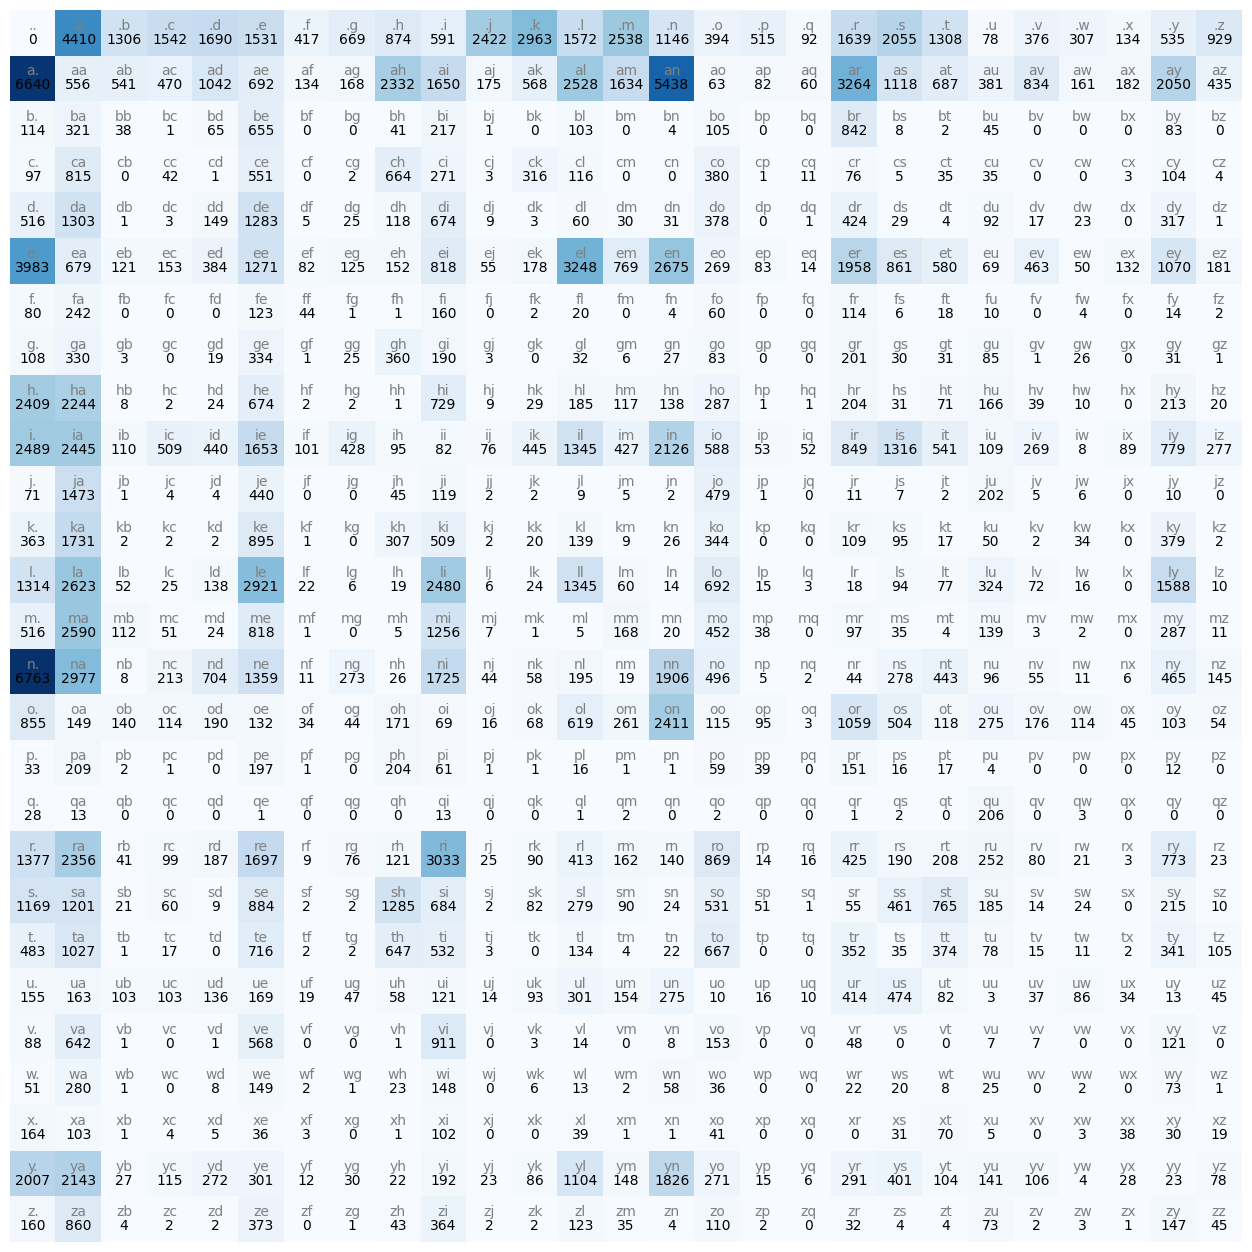

In [23]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')

for i in range(len(itos.keys())):
    for j in range(len(itos.keys())):
        cstr = itos[i] + itos[j]
        plt.text(j, i, cstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="black")
plt.axis("off")

Now we will begin to sample from this distribution to get new names.

The first character will be a dot, so we sample from the first row.

In [24]:
N[0,:]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [25]:
N.shape

torch.Size([27, 27])

In [26]:
N[0]  # Same as doing N[0, :]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

We need a probability vector.
To do that we will normalise the counts, that's why we need floats despite the valuse being integers.

In [27]:
p = N[0].float()  # Probability
p /= p.sum()
p  # Probability distribution for what letter is the first in the word

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [28]:
p.sum()

tensor(1.)

The sum being 1 shows us that this is a good probability distribution

To sample from the diostribution we use torch.multinomial.

Torch.multinomial returns samples from the multinomial probability distribution.

To make everything deterministic we will use a python generator.

In [29]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [30]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([ 9, 18,  2,  5,  3,  1, 13, 11, 11, 22, 11, 15, 26,  2, 18, 13, 10,  1,
        15,  2])

# SAMPLER LOOP

In [31]:
g = torch.Generator().manual_seed(2147483647)
nsamples = 20
for i in range(nsamples):
    ix = 0
    out = []
    while True:
        p = N[ix].float()
        p /= p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


The bigram model as you can see is quite bad because there is no context when predicting the next letter, so it doesn't know if it is the first letter, the last, etc

# Improved efficiency in model by pre-computing probability distribution in matrix instead of in loop

In [50]:
P = N.float()
P /= P.sum(dim=1, keepdim=True)
P.shape

torch.Size([27, 27])

In [51]:
P.sum(1)  # We now have valid distributions at each index

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [52]:
g = torch.Generator().manual_seed(2147483647)
nsamples = 5
for i in range(nsamples):
    ix = 0
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


We could say P is the weights of this model.

Now create a number that determines the quality of the model. To do that we can calculate how good it is at predicting the next letter.

We use Max likelihood estimation. We want the probability of the next correct letter appearing to be as close to 1.

Max likelihood is the product of the probabilities of each character eafter one another.

We want the product of probablitites to be high to indicate a good model because the probability of the dataset is very high.

In [53]:
# log(a*b*c) = log(a) + log(b) + log(c)
# Because likelihood is multiplication, it is handy to use log because it will make calculating it use addition instead of multiplication

log_likelihood = 0.0
for w in words[:3]:
    cs = ['.'] + list(w) + ['.']
    for c1, c2 in zip(cs, cs[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f"{c1}{c2}: {prob:.4f} {logprob:.4f}")
print(f"log_likelihood={log_likelihood:.4f}")

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
log_likelihood=-38.7856


In [54]:
# Loss function
loss = -log_likelihood
loss

tensor(38.7856)

In [55]:
# Use normalised loss function by normalising likelihood:

log_likelihood = 0.0
n=0
for w in words[:3]:
    cs = ['.'] + list(w) + ['.']
    for c1, c2 in zip(cs, cs[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        prob = P[ix1, ix2]
        n+=1
        logprob = torch.log(prob)
        log_likelihood += logprob
        print(f"{c1}{c2}: {prob:.4f} {logprob:.4f}")
print(f"log_likelihood={log_likelihood:.4f}")

loss = -log_likelihood
normalised_negative_loss_likelihood = loss / n

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299
log_likelihood=-38.7856


# GOAL

Maximise likelihood of the data wrt model parameters (statistical modeling)

equivalent to maximising log likelihood because log is monotonic

equivalent to minimising negative log likelihood

equivalent to minimising the average negative log likelihood


Once we have defined a loss function we can compare several models and see which works best.

# Model smoothing
Add fake counts to avoid loss being infinite for samples that the model would never predict.

We add 1 to all the counts. This is called smoothing. We can add any amount we like. The more we add the more uniform our model is.

In [57]:
P = (N+1).float()
P /= P.sum(dim=1, keepdim=True)

g = torch.Generator().manual_seed(2147483647)
nsamples = 5
for i in range(nsamples):
    ix = 0
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
